<a href="https://colab.research.google.com/github/Rmendivil94/retail-fraud-detection/blob/main/notebooks/02_Feature_Engineering_and_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IEEE-CIS Fraud Detection: Feature Engineering and Selection**

##I. Loading the cleaned data from the 'Data Lake'| Cargando la data limpia desde el 'Data Lake'

In [2]:
import pandas as pd
from google.colab import drive

# 1. Set up the 'Data Lake' | Montar el "Data Lake"
drive.mount('/content/drive')

# 2. Automated extraction of the clean Parquet | Ingesta automatizada del Parquet limpio
intake_path = '/content/drive/MyDrive/Portfolio_Fraud_Detection/data/train_cleaned_eda.parquet'
print(f"Starting data intake from: {intake_path}")

train = pd.read_parquet(intake_path)

print(f"Intake completed. Dataset form: {train.shape}")

Mounted at /content/drive
Starting data intake from: /content/drive/MyDrive/Portfolio_Fraud_Detection/data/train_cleaned_eda.parquet
Intake completed. Dataset form: (590540, 229)


##II. Feature Engineering | Ingeniería de variables

###II.a) Dropping high correlated columns | Eliminando columnas altamente relacionadas

In [3]:
import numpy as np

# 1. Define columns to protect | Definir columnas a proteger (Target & IDs)
cols_to_protect = ['TransactionID', 'isFraud', 'TransactionDT']

# 2. Select only numerical variables | Seleccionar solo las variables numéricas
num_cols = [c for c in train.select_dtypes(include = [np.number]).columns if c not in cols_to_protect]

print(f"Correlation matrix for {len(num_cols)} numerical variables...")

# 3. Calculating correlation matrix | Calcular la matriz de correlación
# We use abs() because only the magnitude of the correlation matters | Usamos abs() porque solo interesa la magnitud de la correlación
corr_matrix = train[num_cols].corr().abs()

# 4. Isolate the upper triangle of the matrix to reduce memory usage | Aislar el triángulo superior de la matriz para reducir uso de memoria
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))

# 5. Define threshold and columns to drop | Definir umbral y columnas a eliminar
umbral_corr = 0.90
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > umbral_corr)]

print(f"Redundant columns found (> {umbral_corr*100}% correlation): {len(to_drop)}")

# 6. Drop the redundant columns | Eliminar las columnas redundantes
train = train.drop(columns = to_drop)

print(f"New shape of the dataset: {train.shape}")

Correlation matrix for 213 numerical variables...
Redundant columns found (> 90.0% correlation): 100
New shape of the dataset: (590540, 129)


###II.b) Handling categorical variables | Manejando variables categóricas

>EN: For categorical feature engineering, we implemented a mixed encoding strategy to balance model performance and robustness. We apply Label Encoding to low cardinality variables, optimizing decision tree splits and depth. For high cardinality variables (> 15 unique values), we utilize Smoothed Target Encoding. This allows us to capture the historical fraud risk of complex categories (such as email domains) while reducing the risk of overfitting on small sample sizes.
----



> ES: Para el tratamiento de variables categóricas de texto, implementamos una estrategia de codificación mixta para equilibrar el rendimiento y la robustez del modelo. Utilizamos Label Encoding para variables de baja cardinalidad, lo que optimiza los cortes y la profundidad de los árboles de decisión. Para las variables de alta cardinalidad (> 15 valores únicos), aplicamos Target Encoding Suavizado. Esto nos permite extraer el riesgo histórico de categorías complejas (como dominios de email) mientras evitamos el sobreajuste (overfitting) en muestras pequeñas.


In [4]:
from sklearn.preprocessing import LabelEncoder

# 1. Identify categorical text variables (type: object) | Identificar las variables categóricas de texto (tipo : object)
categorical_cols = train.select_dtypes(include = ['object', 'category']).columns.tolist()
print(f"There are {len(categorical_cols)} categorical variables")

# 2. Separate by cardinality (threshold: 15 unique values) | Separar por cardinalidad (Umbral: 15 categorías únicas)
low_cardinality = [col for col in categorical_cols if train[col].nunique() <= 15]
high_cardinality = [col for col in categorical_cols if train[col].nunique() > 15]

print(f"Low cardinality (to Label Encoding): {len(low_cardinality)}")
print(f"High cardinality (to Smoothed Target Encoding): {len(high_cardinality)}")

There are 13 categorical variables
Low cardinality (to Label Encoding): 12
High cardinality (to Smoothed Target Encoding): 1


In [5]:
# Label Encoding (Low cardinality) | Baja cardinalidad

le = LabelEncoder()
for col in low_cardinality:
    # Replace nulls with 'Unknown' before encoding | Reemplazar nulos con 'Unknown' antes de codificar
    train[col] = train[col].fillna('Unknown')
    train[col] = le.fit_transform(train[col].astype(str))

print("\nLabel Encoding: Complete!")
# Smoothed Target Encoding (High cardinality) | Alta Cardinalidad

def smoothed_target_encoding(df, col, target_col, weight=100):
    """
    Applies Target Encoding with Smoothing to reduce overfitting.
    Aplica Target Encoding suavizado para mitigar el overfitting en muestras pequeñas.
    """
    # Replace nulls with 'Missing' before encoding | Reemplazar nulos con 'Missing' antes de codificar
    df[col] = df[col].fillna('Missing')

    # Calculate globla mean | Calcular la media global
    global_mean = df[target_col].mean()

    # Counts and mean per category | Conteo y meadia por categoría
    agg = df.groupby(col)[target_col].agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']

    # Smoothing factor | Factor de suavizado (Lambda)
    smooth = counts / (counts + weight)

    # Weighted average between local mean and global mean | Promedio ponderado entre media local y media global
    smoothed_means = smooth * means + (1 - smooth) * global_mean

    # Map the calculated values back to the original dataframe | Mapear los valores calculados de vuelta al dataframe original
    return df[col].map(smoothed_means)

# Apply the function to the high cardinality variables | Aplicar la función a las variables de alta cardinalidad
for col in high_cardinality:
    train[col] = smoothed_target_encoding(train, col = col, target_col = 'isFraud', weight = 100)

print("\nSmoothed Target Encoding: Complete!")
# Check for type 0object' columns | Revisamos que ya no queden columnas tipo 'object'
print(f"Columnas de texto restantes: {len(train.select_dtypes(include = ['object']).columns)}")


Label Encoding: Complete!

Smoothed Target Encoding: Complete!
Columnas de texto restantes: 0


###II.c) Selecting most important variables | Seleccionando las variables más importantes

Training base model LightGBM with 126 variables...


/tmp/ipykernel_529/2105776395.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


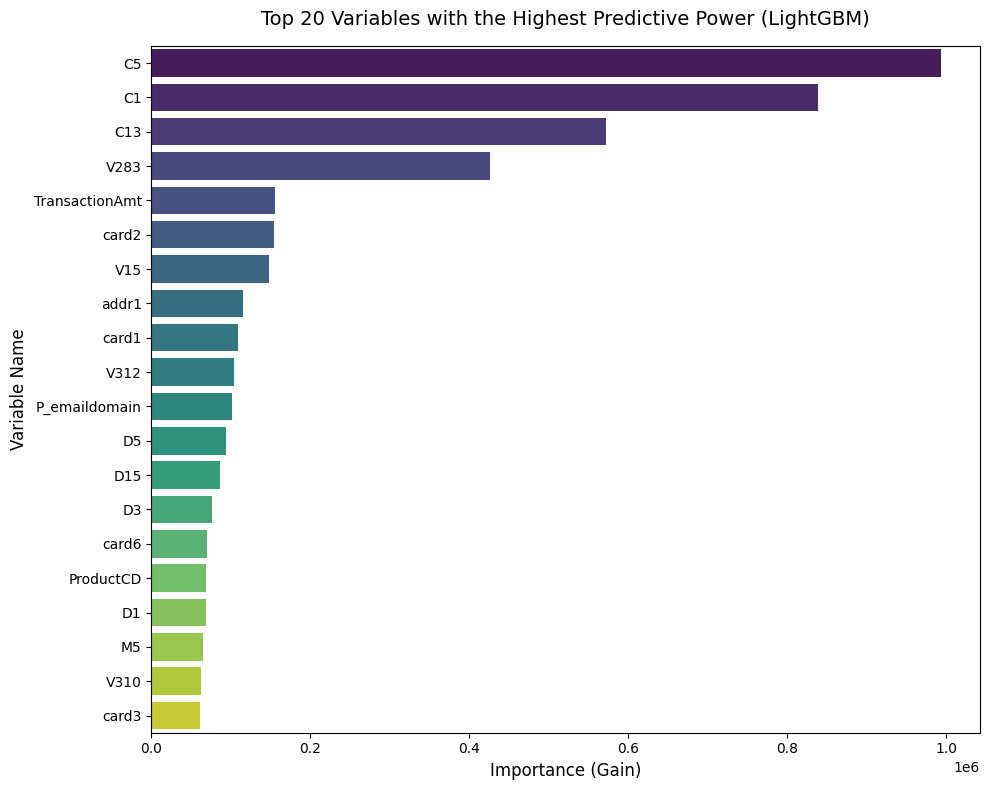


Variables with no importance (Importance = 0): 21


In [6]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate independent variables (X) from the dependent variable (y) | Separar variables independientes (X) de la dependiente (y)
# Drop the 'TransactionID' and the 'TransactionDT' | Eliminar el 'TransactionID' y el 'TransactionDT'
cols_to_drop = ['TransactionID', 'isFraud', 'TransactionDT']
X = train.drop(columns=[col for col in cols_to_drop if col in train.columns])
y = train['isFraud']

print(f"Training base model LightGBM with {X.shape[1]} variables...")

# 2. Set up the base model | Configurar el modelo base
# Calculate the weight to compensate for the imbalance | Calcular el peso para compensar el desbalanceo
pos_weight = (len(y) - sum(y)) / sum(y)

base_model = lgb.LGBMClassifier(
    n_estimators = 100,      # 100 trees | 100 árboles
    random_state = 42,       # Seed | Semilla
    n_jobs = -1,             # Use all the processor's core | Usar todos los núcleos del procesador
    scale_pos_weight = pos_weight, # Fraud's weight | Peso de fraudes
    importance_type='gain',  # Gain instead Cuts | Ganancia en vez de Cortes
    verbose = -1
)

# 3. Train the model | Entrenar el modelo
base_model.fit(X , y)

# 4. Extract the importance of the variables in a DataFrame | Extraer la importancia de las variables en un DataFrame
feature_imp = pd.DataFrame({
    'Value': base_model.feature_importances_,
    'Feature': X.columns
})

# Sort values descending | Ordenar importancia descendente
feature_imp = feature_imp.sort_values(by = "Value", ascending = False).reset_index(drop = True)

# 5. Top 20 barplot | Graficar el Top 20
plt.figure(figsize = (10 , 8))
sns.barplot(
    x = "Value",
    y = "Feature",
    data = feature_imp.head(20),
    palette = 'viridis'
)
plt.title('Top 20 Variables with the Highest Predictive Power (LightGBM)', fontsize = 14, pad = 15)
plt.xlabel('Importance (Gain)', fontsize = 12)
plt.ylabel('Variable Name', fontsize = 12)
plt.tight_layout()
plt.show()

# Variables with no importance | Variables sin importancia
zero_importance = feature_imp[feature_imp['Value'] == 0]
print(f"\nVariables with no importance (Importance = 0): {len(zero_importance)}")

>EN: From an initial set of 126 features, the baseline model discarded 21 for having strictly zero importance (absolute noise). While the remaining 105 features exhibited some degree of predictive signal, many formed a 'long tail' of marginal contributions. To prevent overfitting and ensure computational efficiency in a production environment, we applied the Elbow Method on the cumulative information gain. This allowed us to isolate the subset of features that capture 99% of the predictive power, eliminate statistical noise and ensuring a lighter, more robust final model.


---


> ES: A partir de un conjunto inicial de 126 variables, el modelo base descartó 21 por tener importancia nula (ruido absoluto). Aunque las 105 variables restantes presentaban algún grado de señal predictiva, muchas de ellas conformaban una 'cola larga' de aportes marginales. Para prevenir el sobreajuste (overfitting) y garantizar la eficiencia computacional en producción, aplicamos el Método del Codo sobre la ganancia de información acumulada. Esto nos permitió aislar el subconjunto variables que concentra el 99% del poder predictivo, descartando el ruido y asegurando un modelo final más ligero y robusto.


##### **Elbow Method | Método del codo**

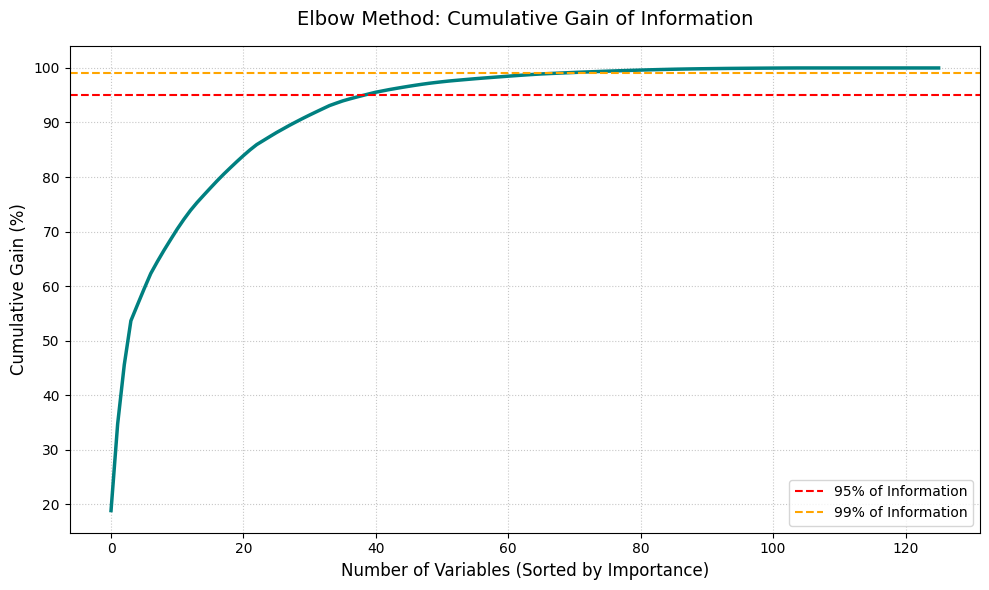

In [7]:
# 1. Gain percentage of each variable | Porcentaje de ganancia de cada variable
feature_imp['Gain_Percentage'] = 100 * (feature_imp['Value'] / feature_imp['Value'].sum())

# 2. Cumulative_Gain | Ganancia acumulada
feature_imp['Cumulative_Gain'] = feature_imp['Gain_Percentage'].cumsum()

# 3. Elbow Method | Método del Codo
plt.figure(figsize = (10 , 6))
sns.lineplot(x = feature_imp.index, y = feature_imp['Cumulative_Gain'], color = 'teal', linewidth = 2.5)

# Reference lines at 95% and 99% | Líneas de referencia en 95% y 99%
plt.axhline(y = 95, color = 'red', linestyle = '--', label = '95% of Information')
plt.axhline(y = 99, color = 'orange', linestyle = '--', label = '99% of Information')

plt.title('Elbow Method: Cumulative Gain of Information', fontsize = 14, pad = 15)
plt.xlabel('Number of Variables (Sorted by Importance)', fontsize = 12)
plt.ylabel('Cumulative Gain (%)', fontsize = 12)
plt.legend()
plt.grid(True, linestyle = ':', alpha = 0.7)
plt.tight_layout()
plt.show()

>EN: By applying the Elbow Method to Cumulative Information Gain, we identified that 99% of the model's predictive power resides in a fraction of the dataset. We executed an algorithmic pruning, reducing the feature's set from 126 columns to an subset of 67 features. This optimization eradicates the 'long tail' of statistical noise, prevents overfitting, and guarantees low inference latency, a non negotiable requirement for deploying this model in a real time processing environment.


---
>ES: Aplicando el Método del Codo sobre la Ganancia de Información Acumulada, identificamos que el 99% del poder predictivo del modelo reside en una fracción de los datos. Ejecutamos un recorte algorítmico estricto, reduciendo el grupo de características de 126 a 67 variables. Esta optimización erradica la 'cola larga' de ruido estadístico, previene el sobreajuste (overfitting) y garantiza una latencia de inferencia baja, un requisito no negociable para el despliegue de este modelo en un entorno de procesamiento en tiempo real.


In [8]:
# 4. Keep the variables that explain 99% | Manetener las variables que explican el 99%
threshold_gain = 99
top_features = feature_imp[feature_imp['Cumulative_Gain'] <= threshold_gain]['Feature'].tolist()

print(f"Number of features before elbow: {len(feature_imp)}")
print(f"Number of features after elbow: {len(top_features)}")
print(f"Dropped features: {len(feature_imp) - len(top_features)}")

# 5. Aplicar el recorte al dataset final (sin olvidar proteger nuestro Target e ID)
cols_to_keep = ['TransactionID', 'isFraud', 'TransactionDT'] + top_features
train_final = train[cols_to_keep]

print(f"\nNew dataset shape: {train_final.shape}")

Number of features before elbow: 126
Number of features after elbow: 67
Dropped features: 59

New dataset shape: (590540, 70)


##III. Saving the dataset's final version | Guardando la versión final del conjunto de datos

In [9]:
import os

# 1. Directory path | Ruta del directorio
path_directory = '/content/drive/MyDrive/Portfolio_Fraud_Detection/data'
os.makedirs(path_directory, exist_ok = True)

# 2. Save the final train dataset | Guardar el dataset definitivo
final_path_save = f'{path_directory}/train_final_features.parquet'
train_final.to_parquet(final_path_save, index = False)

print(f"Final dataset saved in: \n{final_path_save}")

Final dataset saved in: 
/content/drive/MyDrive/Portfolio_Fraud_Detection/data/train_final_features.parquet
